In [ ]:
from concurrent.futures import ThreadPoolExecutor
from fipilot.resume_extraction import ResumeExtract
from fipilot.configs.settings import cfg

extractor = ResumeExtract(
    yolo_model=cfg.YOLO_MODEL,
    llm_model=cfg.LLM_MODEL,
    dpi=300,
    max_workers=cfg.MAX_WORKER,
    max_retries=cfg.MAX_RETRIES
)

pdf_files = sorted(cfg.INPUT_DATA_DIR.rglob("*.pdf"))

def process_single_pdf(pdf_path):
    try:
        saved_files = extractor.pdf_to_images(pdf_path, cfg.OUTPUT_DATA_DIR)
        print(f"Đã xử lý xong: {pdf_path.name} -> Xuất {len(saved_files)} ảnh.")
        return saved_files
    except Exception as e:
        print(f"❌ Lỗi khi xử lý file {pdf_path.name}: {str(e)}")
        return []


with ThreadPoolExecutor(max_workers=cfg.MAX_WORKER) as executor:
    results = list(executor.map(process_single_pdf, pdf_files))

In [1]:
import os

folder_path = '/home/hoai/user/resource/fipilot/backend/data/raw/resumes_copy/ai-se'

for index, file_name in enumerate(os.listdir(folder_path)):
    name, ext = os.path.splitext(file_name)
    file_path = os.path.join(folder_path, file_name)

    # Kiểm tra nếu là file thì mới xử lý
    if os.path.isfile(file_path):
        new_name = f"{index}{ext}"
        new_path = os.path.join(folder_path, new_name)
        os.rename(file_path, new_path)
        print(f"Đã đổi: {file_name} -> {new_name}")

Đã đổi: Resume_LamNguyen.pdf -> 0.pdf
Đã đổi: AI_Engineer_candidate_resume-10841475.pdf -> 1.pdf
Đã đổi: Fullstack_Developer_candidate_thanh-huy-nguyen-13690268.pdf -> 2.pdf
Đã đổi: 92.pdf -> 3.pdf
Đã đổi: 272.pdf -> 4.pdf
Đã đổi: Kỹ_Sư_Phần_Mềm_candidate_ky-su-phan-mem-10091175.pdf -> 5.pdf
Đã đổi: venkatakrishnan-cv.pdf -> 6.pdf
Đã đổi: Computer_Vision_Engineer_candidate_resume-13563734.pdf -> 7.pdf
Đã đổi: Backend_Developer_candidate_long-nguyen-10039423.pdf -> 8.pdf
Đã đổi: khoa-CV2.pdf -> 9.pdf
Đã đổi: CV-AlvinJopanda.pdf -> 10.pdf
Đã đổi: Backend_Developer_candidate_backend-developer-10312677.pdf -> 11.pdf
Đã đổi: Java_Backend_Developer_candidate_java-backend-developer-10349292.pdf -> 12.pdf
Đã đổi: React_Native_Developer_candidate_resume-8798707.pdf -> 13.pdf
Đã đổi: IT_Software_Staff_candidate_hieu-nghia-le-13254057.pdf -> 14.pdf
Đã đổi: Data_Engineer_candidate_big-data-data-engineer-3876523.pdf -> 15.pdf
Đã đổi: React_Native_Developer_candidate_le-truong-tin-10319802.pdf -> 16

In [4]:
!mkdir -p /home/hoai/user/resource/fipilot/backend/data/processed/layout_data/images
!mkdir -p /home/hoai/user/resource/fipilot/backend/data/processed/layout_data/labels

!cp /home/hoai/user/resource/fipilot/backend/data/processed/resume_images/*.png /home/hoai/user/resource/fipilot/backend/data/processed/layout_data/images

In [ ]:
import os
import json
import shutil
import yaml

# 1. Đường dẫn cấu hình (Hãy điều chỉnh cho đúng với môi trường của bạn nếu cần)
NDJSON_PATH = "/home/hoai/user/resource/fipilot/backend/data/processed/resume_images/0resume-imagesv.ndjson"
SRC_IMAGE_DIR = "/home/hoai/user/resource/fipilot/backend/data/processed/resume_images"
OUTPUT_DIR = "/home/hoai/user/resource/fipilot/backend/data/processed/layout_data"

# 2. Khởi tạo cấu trúc thư mục YOLO
splits = ["train", "val", "test"]
for split in splits:
    os.makedirs(os.path.join(OUTPUT_DIR, "images", split), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "labels", split), exist_ok=True)

class_names = {}
processed_images = 0

# 3. Đọc file ndjson và phân loại dữ liệu
print("Đang xử lý file ndjson...")
with open(NDJSON_PATH, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line.strip())
        
        # Đọc thông tin lớp (classes) từ dòng dataset đầu tiên
        if data.get("type") == "dataset":
            class_names = {int(k): v for k, v in data.get("class_names", {}).items()}
            continue
            
        # Xử lý thông tin từng ảnh và bounding box
        if data.get("type") == "image":
            jpg_name = data.get("file")
            stem = os.path.splitext(jpg_name)[0]
            png_name = f"{stem}.png"
            split = data.get("split", "train")
            
            src_image_path = os.path.join(SRC_IMAGE_DIR, png_name)
            dst_image_path = os.path.join(OUTPUT_DIR, "images", split, png_name)
            
            if os.path.exists(src_image_path):
                # Sao chép tệp ảnh vào thư mục split tương ứng
                shutil.copy2(src_image_path, dst_image_path)
                
                # Tạo file nhãn YOLO (.txt)
                label_filename = f"{stem}.txt"
                dst_label_path = os.path.join(OUTPUT_DIR, "labels", split, label_filename)
                
                boxes = data.get("annotations", {}).get("boxes", [])
                with open(dst_label_path, "w", encoding="utf-8") as fl:
                    for box in boxes:
                        class_id = int(box[0])
                        x_center = box[1]
                        y_center = box[2]
                        width = box[3]
                        height = box[4]
                        
                        # Ghi theo định dạng YOLO chuẩn: class_id x_center y_center width height
                        fl.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
                processed_images += 1
            else:
                print(f"Cảnh báo: Không tìm thấy ảnh thực tế {png_name}")

# 4. Tự động tạo tệp cấu hình dataset.yaml
dataset_yaml = {
    "path": "/" + os.path.abspath(OUTPUT_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": class_names if class_names else {0: "table", 1: "photo", 2: "text"}
}

yaml_path = os.path.join(OUTPUT_DIR, "dataset.yaml")
with open(yaml_path, "w", encoding="utf-8") as fy:
    yaml.dump(dataset_yaml, fy, default_flow_style=False, sort_keys=False)

print("\n--- HOÀN THÀNH ---")
print(f"Đã xử lý và sao chép thành công: {processed_images} ảnh và nhãn tương ứng.")
print(f"Thư mục YOLO dataset được tạo tại: {os.path.abspath(OUTPUT_DIR)}")
print(f"File cấu hình YOLO: {yaml_path}")

Đang xử lý file ndjson...

--- HOÀN THÀNH ---
Đã xử lý và sao chép thành công: 3855 ảnh và nhãn tương ứng.
Thư mục YOLO dataset được tạo tại: /home/hoai/user/resource/fipilot/backend/data/processed/layout_data
File cấu hình YOLO: /home/hoai/user/resource/fipilot/backend/data/processed/layout_data/dataset.yaml


In [8]:
import os

# 1. Đường dẫn tới thư mục gốc của YOLO dataset
DATASET_DIR = "/home/hoai/user/resource/fipilot/backend/data/processed"

def generate_txt_list(split_name, output_txt_name):
    """
    Quét thư mục ảnh của một split (train/val) và ghi đường dẫn tuyệt đối ra file txt
    """
    image_dir = os.path.join(DATASET_DIR, "images", split_name)
    output_txt_path = os.path.join(DATASET_DIR, output_txt_name)
    
    if not os.path.exists(image_dir):
        print(f"Lỗi: Không tìm thấy thư mục ảnh tại: {image_dir}")
        return
        
    # Lọc các file ảnh (hỗ trợ các đuôi phổ biến)
    valid_extensions = (".png", ".jpg", ".jpeg", ".webp")
    image_paths = []
    
    for filename in os.listdir(image_dir):
        if filename.lower().endswith(valid_extensions):
            # Lấy đường dẫn tuyệt đối
            abs_path = os.path.abspath(os.path.join(image_dir, filename))
            image_paths.append(abs_path)
            
    # Sắp xếp và ghi danh sách vào file txt
    with open(output_txt_path, "w", encoding="utf-8") as f:
        for path in sorted(image_paths):
            f.write(path + "\n")
            
    print(f"-> Đã tạo thành công: {output_txt_name} ({len(image_paths)} ảnh).")

# 2. Thực thi tạo 2 file train.txt và val.txt
print("Đang quét thư mục ảnh và tạo file danh sách...")
generate_txt_list(split_name="train", output_txt_name="train.txt")
generate_txt_list(split_name="val", output_txt_name="val.txt")

Đang quét thư mục ảnh và tạo file danh sách...
-> Đã tạo thành công: train.txt (3084 ảnh).
-> Đã tạo thành công: val.txt (384 ảnh).


Đang hiển thị thử ảnh: 3945.png


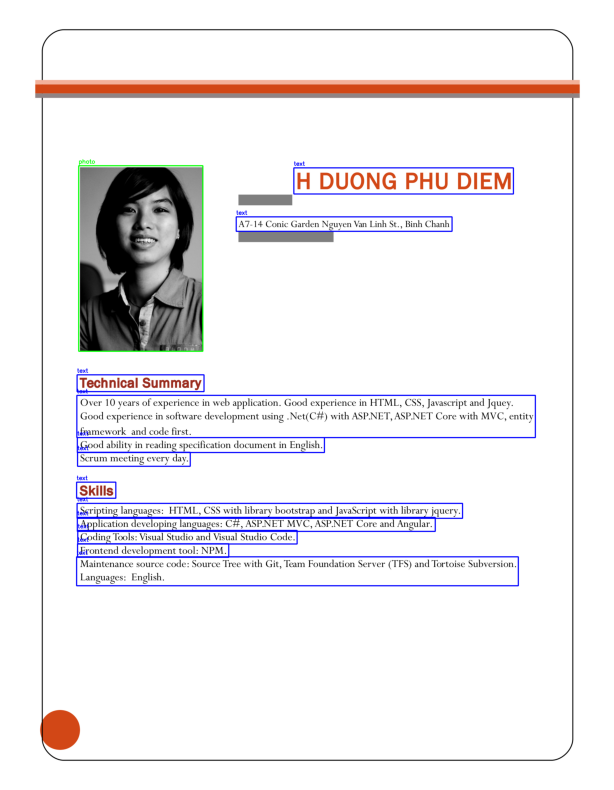

In [7]:
import cv2
import random
import matplotlib.pyplot as plt

def draw_yolo_labels(image_path, label_path, class_names):
    # Đọc ảnh
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    # Định nghĩa màu sắc trực quan cho 3 nhãn chính
    colors = {
        0: (255, 0, 0),    # Đỏ cho Table
        1: (0, 255, 0),    # Xanh lá cho Photo
        2: (0, 0, 255)     # Xanh dương cho Text
    }
    
    # Vẽ các bounding boxes
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_c, y_c, box_w, box_h = map(float, parts[1:])
                    
                    # Chuyển đổi tọa độ YOLO (tỉ lệ 0-1) về pixel thực tế của ảnh
                    x1 = int((x_c - box_w / 2) * w)
                    y1 = int((y_c - box_h / 2) * h)
                    x2 = int((x_c + box_w / 2) * w)
                    y2 = int((y_c + box_h / 2) * h)
                    
                    color = colors.get(class_id, (255, 165, 0)) # Mặc định màu cam nếu class lạ
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
                    
                    label_text = class_names.get(class_id, f"Class {class_id}")
                    cv2.putText(img, label_text, (x1, y1 - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
                                
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# Chọn ngẫu nhiên một ảnh từ thư mục train vừa tạo để hiển thị kiểm tra
train_img_dir = os.path.join(OUTPUT_DIR, "images/train")
train_label_dir = os.path.join(OUTPUT_DIR, "labels/train")
all_train_images = [f for f in os.listdir(train_img_dir) if f.endswith(".png")]

if all_train_images:
    sample_img = random.choice(all_train_images)
    sample_label = f"{os.path.splitext(sample_img)[0]}.txt"
    
    print(f"Đang hiển thị thử ảnh: {sample_img}")
    draw_yolo_labels(
        os.path.join(train_img_dir, sample_img),
        os.path.join(train_label_dir, sample_label),
        dataset_yaml["names"]
    )
else:
    print("Không tìm thấy ảnh nào trong tập train để vẽ.")

In [ ]:
# Dưới đây là đoạn mã Python đã được cập nhật. Ngoài việc tạo các thư mục ảnh và nhãn như trước, đoạn mã này sẽ:

# 1.  Tự động thu thập đường dẫn tuyệt đối của tất cả các ảnh sau khi được chuyển vào tập `train` và `val`.
# 2.  Tạo ra hai file **`train.txt`** và **`val.txt`** nằm trong thư mục gốc của dataset (`yolo_dataset/`), liệt kê đường dẫn tuyệt đối của từng ảnh tương ứng.
# 3.  Cập nhật file **`dataset.yaml`** để trỏ trực tiếp đến `train.txt` và `val.txt` theo đúng chuẩn cấu hình của YOLO.

# ### Cell 1: Mã nguồn chuyển đổi và tạo file `train.txt`, `val.txt`

# ```python
# import os
# import json
# import shutil
# import yaml

# # 1. Đường dẫn cấu hình
# NDJSON_PATH = "./resume_images/0resume-imagesv.ndjson"
# SRC_IMAGE_DIR = "./resume_images"
# OUTPUT_DIR = "./yolo_dataset"

# # 2. Khởi tạo cấu trúc thư mục YOLO
# splits = ["train", "val", "test"]
# for split in splits:
#     os.makedirs(os.path.join(OUTPUT_DIR, "images", split), exist_ok=True)
#     os.makedirs(os.path.join(OUTPUT_DIR, "labels", split), exist_ok=True)

# class_names = {}
# processed_images = 0

# # Danh sách lưu đường dẫn ảnh cho train.txt và val.txt
# train_paths = []
# val_paths = []

# # 3. Đọc file ndjson và phân loại dữ liệu
# print("Đang xử lý file ndjson...")
# with open(NDJSON_PATH, "r", encoding="utf-8") as f:
#     for line in f:
#         data = json.loads(line.strip())
        
#         # Đọc thông tin lớp (classes) từ dòng dataset đầu tiên
#         if data.get("type") == "dataset":
#             class_names = {int(k): v for k, v in data.get("class_names", {}).items()}
#             continue
            
#         # Xử lý thông tin từng ảnh và bounding box
#         if data.get("type") == "image":
#             jpg_name = data.get("file")
#             stem = os.path.splitext(jpg_name)[0]
#             png_name = f"{stem}.png"
#             split = data.get("split", "train")
            
#             src_image_path = os.path.join(SRC_IMAGE_DIR, png_name)
#             dst_image_path = os.path.join(OUTPUT_DIR, "images", split, png_name)
            
#             if os.path.exists(src_image_path):
#                 # Sao chép tệp ảnh vào thư mục split tương ứng
#                 shutil.copy2(src_image_path, dst_image_path)
                
#                 # Lưu đường dẫn tuyệt đối của ảnh vào danh sách tương ứng
#                 abs_dst_image_path = os.path.abspath(dst_image_path)
#                 if split == "train":
#                     train_paths.append(abs_dst_image_path)
#                 elif split == "val":
#                     val_paths.append(abs_dst_image_path)
                
#                 # Tạo file nhãn YOLO (.txt)
#                 label_filename = f"{stem}.txt"
#                 dst_label_path = os.path.join(OUTPUT_DIR, "labels", split, label_filename)
                
#                 boxes = data.get("annotations", {}).get("boxes", [])
#                 with open(dst_label_path, "w", encoding="utf-8") as fl:
#                     for box in boxes:
#                         class_id = int(box[0])
#                         x_center = box[1]
#                         y_center = box[2]
#                         width = box[3]
#                         height = box[4]
                        
#                         # Ghi theo định dạng YOLO chuẩn: class_id x_center y_center width height
#                         fl.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
#                 processed_images += 1
#             else:
#                 print(f"Cảnh báo: Không tìm thấy ảnh thực tế {png_name}")

# # 4. Ghi danh sách đường dẫn ra file train.txt và val.txt
# train_txt_path = os.path.join(OUTPUT_DIR, "train.txt")
# with open(train_txt_path, "w", encoding="utf-8") as ft:
#     for p in train_paths:
#         ft.write(p + "\n")

# val_txt_path = os.path.join(OUTPUT_DIR, "val.txt")
# with open(val_txt_path, "w", encoding="utf-8") as fv:
#     for p in val_paths:
#         fv.write(p + "\n")

# # 5. Tạo tệp cấu hình dataset.yaml trỏ tới các file text vừa tạo
# dataset_yaml = {
#     "path": os.path.abspath(OUTPUT_DIR),
#     "train": "train.txt",   # Trỏ trực tiếp tới file train.txt
#     "val": "val.txt",       # Trỏ trực tiếp tới file val.txt
#     "test": "images/test",  # Giữ nguyên cấu trúc thư mục cho test (nếu có)
#     "names": class_names if class_names else {0: "table", 1: "photo", 2: "text"}
# }

# yaml_path = os.path.join(OUTPUT_DIR, "dataset.yaml")
# with open(yaml_path, "w", encoding="utf-8") as fy:
#     yaml.dump(dataset_yaml, fy, default_flow_style=False, sort_keys=False)

# print("\n--- HOÀN THÀNH ---")
# print(f"Đã xử lý: {processed_images} ảnh.")
# print(f"Đã tạo file train.txt ({len(train_paths)} ảnh): {train_txt_path}")
# print(f"Đã tạo file val.txt ({len(val_paths)} ảnh): {val_txt_path}")
# print(f"Thư mục YOLO dataset: {os.path.abspath(OUTPUT_DIR)}")
# print(f"File cấu hình YOLO: {yaml_path}")
# ```